In [95]:
import numpy as np
from numpy import random as nprnd
import random as rnd
import pandas as pd
import string as str
from math import *
import itertools

#scipy stat
import scipy.stats as ss
from scipy import stats
from scipy.stats import linregress,norm, kurtosis, moment,iqr,binom, binomtest,gmean
from scipy.stats import expon,zscore,zmap
from scipy.stats import t,ttest_ind
from scipy.stats import f,f_oneway
from scipy.stats import boxcox
from scipy.stats import skewnorm,skew
from scipy.stats import pearsonr
from scipy.linalg import toeplitz
from scipy.interpolate import CubicSpline
#scipy signals library
from scipy import signal
#scipy calculus library
import scipy.integrate as spi



#scipy chi
from scipy.stats import chi,chi2_contingency,chi2

import math

import os
import time

import csv

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as style

import seaborn as sns
# Pkg import Date Time
from datetime import datetime
from datetime import timedelta
from pandas.tseries.offsets import Hour, Minute
from pandas.tseries.offsets import Day, MonthEnd
import pytz
from pandas.tseries.frequencies import to_offset
#import arviz as az
import plotly
from sympy import symbols, Eq, solve
import re #extract cofficient

###################################################
'''Statemodels'''
###################################################
# # Ordinary Least Squares
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
import statsmodels.stats.power as smp
from statsmodels.stats.anova import anova_lm

from statsmodels.regression.linear_model import OLS
from statsmodels.stats.outliers_influence import OLSInfluence,variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson,omni_normtest,\
                                        jarque_bera
from patsy import dmatrices,dmatrix

from zlib import crc32
import hashlib

###################################################
'''sklearn'''
###################################################
# model_selection
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import KFold, StratifiedKFold, StratifiedShuffleSplit
from sklearn.model_selection import learning_curve
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import validation_curve
from sklearn.model_selection import GridSearchCV

# Multiclass
from sklearn.multiclass import OneVsOneClassifier,OneVsRestClassifier

# Base
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.base import clone

# preprocessing
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.preprocessing import PolynomialFeatures,label_binarize

# pipeline
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline

# datasets
from sklearn.datasets import fetch_openml
from sklearn.datasets import make_blobs
from sklearn import datasets
from sklearn.datasets import make_classification
from sklearn.datasets import load_iris
from sklearn.datasets import load_sample_image

# calibration
from sklearn.calibration import CalibratedClassifierCV
from sklearn.calibration import calibration_curve

# metrics

from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import brier_score_loss

from sklearn.metrics import mean_squared_error,mean_absolute_error
from sklearn.metrics import confusion_matrix,precision_score,\
                            recall_score,f1_score,\
                            classification_report, accuracy_score,\
                            precision_recall_curve,\
                            roc_curve,auc, roc_auc_score,\
                            ConfusionMatrixDisplay,\
                            root_mean_squared_error    
                            
# neural_network
from sklearn.neural_network import MLPClassifier,\
                                   MLPRegressor,\
                                   BernoulliRBM

# tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz

# linear_model
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDClassifier
from sklearn.linear_model import Ridge
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import Perceptron
#SVM
from sklearn.svm import SVC
from sklearn.svm import LinearSVC

from graphviz import Source

#ensemble
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.ensemble import BaggingClassifier

#decomposition
from sklearn.decomposition import PCA

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

from sklearn.cluster import MiniBatchKMeans

import tensorflow as tf
from tensorflow import keras

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tarfile
import urllib.request
#====================================
import tensorflow as tf
import h5py
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from tensorflow.keras import initializers
import visualkeras


from tensorflow.keras.models import Sequential
from tensorflow.keras.models import Model
# layers
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Normalization,BatchNormalization
#CNN
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
#activations
from tensorflow.keras.activations import sigmoid
#utils
from tensorflow.keras.utils import to_categorical

#callbacks
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import TensorBoard
from tensorflow.keras.callbacks import LambdaCallback
from tensorflow.keras.callbacks import TerminateOnNaN
from tensorflow.keras.callbacks import CSVLogger
from tensorflow.keras.callbacks import LearningRateScheduler
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import Callback

#preprocessing 
from tensorflow.keras.preprocessing import image
import sys
from copy import deepcopy
import kagglehub


In [96]:
def tableDispFormatt(yourString):
    fixLen = 90
    startLine = '==============================='
    textLen = len(yourString)
    endLineLen = fixLen - (len(startLine)+textLen)
    endLine = ''
    for i in np.arange(0,endLineLen,1):
        endLine += '='
    print(startLine,yourString,endLine)

In [97]:
def extract_ols_stats(fit_obj):
    """
    Extracts key statistics from a statsmodels OLS.fit() object
    and returns them in a pandas DataFrame.
    """
    # Robust covariance results
    robust = {
        "HC0": fit_obj.get_robustcov_results(cov_type="HC0"),
        "HC1": fit_obj.get_robustcov_results(cov_type="HC1"),
        "HC2": fit_obj.get_robustcov_results(cov_type="HC2"),
        "HC3": fit_obj.get_robustcov_results(cov_type="HC3"),
    }

    stats_dict = {
        "R-squared": fit_obj.rsquared,
        "Adj. R-squared": fit_obj.rsquared_adj,
        "F-statistic": fit_obj.fvalue,
        "Prob (F-statistic)": fit_obj.f_pvalue,
        "Log-Likelihood": fit_obj.llf,
        "fvalue": fit_obj.fvalue,
        "f_pvalue": fit_obj.f_pvalue,
        "use_t": fit_obj.use_t,
        "AIC": fit_obj.aic,
        "BIC": fit_obj.bic,
        "HC0_se": robust["HC0"].bse,
        "HC1_se": robust["HC1"].bse,
        "HC2_se": robust["HC2"].bse,
        "HC3_se": robust["HC3"].bse,
        "_HCCM": {k: v.cov_params() for k, v in robust.items()},
        "bse": fit_obj.bse,
        "cov_HC0": robust["HC0"].cov_params(),
        "cov_HC1": robust["HC1"].cov_params(),
        "cov_HC2": robust["HC2"].cov_params(),
        "cov_HC3": robust["HC3"].cov_params(),
        "No. Observations": fit_obj.nobs,
        "df_model": fit_obj.df_model,
        "df_resid": fit_obj.df_resid,
        "mse_model": fit_obj.mse_model,
        "mse_resid": fit_obj.mse_resid,
        "mse_total": fit_obj.mse_total,
        "ssr": fit_obj.ssr,
        "resid": fit_obj.resid,
        "resid_pearson": fit_obj.resid_pearson,
        "wresid": fit_obj.wresid,
        "rsquared": fit_obj.rsquared,
        "rsquared_adj": fit_obj.rsquared_adj,
        "nobs": fit_obj.nobs,
        "uncentered_tss": fit_obj.uncentered_tss,
        "centered_tss": fit_obj.centered_tss,
        "condition_number": fit_obj.condition_number,
    }

    # Convert to DataFrame (single row)
    df = pd.DataFrame([stats_dict])
    return df

In [98]:
path = os.path.join(os.getcwd(), 'DataSet', 'auto-mpg_1.csv')
df = pd.read_csv(path)

# Clean horsepower column
df["horsepower"] = pd.to_numeric(df["horsepower"], errors="coerce")
df = df.dropna(subset=["horsepower"])
df.drop(['car name'],axis='columns',inplace=True)

In [99]:
auto_mpg_mapping_dict = {
    'CYL': 'cylinders',
    'DISP': 'displacement',
    'HP': 'horsepower',
    'WGT': 'weight',
    'ACC': 'acceleration',
    'MYR': 'model year',
    'ORG2': 'origin_2',
    'ORG3': 'origin_3'
}
# Get keys as a list
keys_list = list(auto_mpg_mapping_dict.keys())
print(keys_list)

['CYL', 'DISP', 'HP', 'WGT', 'ACC', 'MYR', 'ORG2', 'ORG3']


In [100]:
# One-hot encode 'origin'
df_encoded = pd.get_dummies(df, columns=['origin'], drop_first=True)

#### Regression Analysis (Auto MPG Dataset)

For statistical regression analysis on the Auto MPG dataset, I plan to drop categorical variables and the model year feature. Although earlier exploration showed that both origin and model year are highly influential to MPG (miles per gallon), they represent external factors rather than direct physical attributes of the car.

- Origin (USA, Japan, Europe) reflects regional manufacturing philosophies and business strategies, which certainly affect MPG. However, it is not essential for a purely statistical analysis focused on technical design.

- Model year captures technological progress over time, but again, it is not a physical property of the vehicle.

By focusing only on numerical variables such as cylinders, displacement, horsepower, weight, and acceleration, we can better understand the technical drivers of fuel consumption.
The dataset does exhibit strong multicollinearity among these predictors. When categorical and numerical variables are combined, applying statistical diagnostics like F‑statistic, t‑statistic, or Cook’s distance becomes more complex and less interpretable. Dropping categorical variables simplifies the analysis, allowing us to concentrate on the technical aspects of vehicle design and to apply multicollinearity diagnostics more effectively.

For predictive modeling, categorical variables like origin and model year can improve accuracy. But for technical regression analysis, focusing on numerical predictors provides clearer insights into the engineering factors that drive fuel efficiency, while also making multicollinearity diagnostics more manageable.


#### Model Formuals For regressions Analysis

In [101]:
formulas_single_line_sol_with_indecator_var = \
'mpg ~ CYL + DISP + HP + WGT + ACC + MYR + ORG2 + ORG3 + CYL*ORG2 + CYL*ORG3 + DISP*ORG2 + DISP*ORG3 + HP*ORG2 + HP*ORG3 + WGT*ORG2 + WGT*ORG3 + ACC*ORG2 + ACC*ORG3 + MYR*ORG2 + MYR*ORG3'
formulas_two_line_sol = 'mpg ~ CYL + DISP + HP + WGT + ACC + MYR + ORG2 + ORG3'

# Models with numerical variable only
formulas_numericals_only = 'mpg ~ cylinders + displacement + horsepower + weight + acceleration'
# Models Fuel Efficiency Model (empirical regression)

# Performance Model


In [102]:
dfScaled = df.copy()
# Select regressors
X = dfScaled[['cylinders', 'displacement', 'horsepower', 'weight','acceleration']]
# Apply standard scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Replace scaled values back into dataframe
dfScaled[['cylinders', 'displacement', 'horsepower', 'weight','acceleration']] = X_scaled

#### Methodology (How to proceed):

During the exploratory data analysis, several predictor variables demonstrated non‑linear relationships with the response variable. To ensure model validity and improve predictive performance, it is essential to apply appropriate transformations and extend the model to capture higher‑order effects. The modeling process will therefore proceed in a structured sequence:

#### Transformation of the Dependent Variable

The response variable, miles per gallon (mpg), will first be subjected to a Box–Cox transformation. This procedure identifies an optimal power parameter \lambda  that stabilizes variance and improves the normality of residuals, thereby enhancing the suitability of linear regression assumptions.

#### Transformation of Independent Variables

Predictor variables (X) will be examined for skewness, heteroscedasticity, and non‑linear patterns. Where necessary, transformations (e.g., logarithmic, square root, or reciprocal) will be applied to reduce distortion and improve linearity with the dependent variable.

#### Polynomial Model Extension

To capture complex relationships beyond simple linearity, polynomial regression terms of degree n will be introduced. This allows the model to approximate non‑linear trends while maintaining interpretability within the regression framework. The choice of polynomial order will be guided by diagnostic measures such as adjusted R^2, AIC, BIC, and residual analysis.


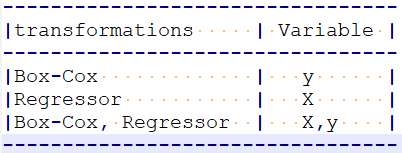

## Transformations

#### 1. Box-Cox Procedure (apply on y):

$y^{(\lambda )}=\begin{cases}\frac{y^{\lambda }-1}{\lambda y^{\lambda -1}},&\lambda \ne 0\\ \.{y}\ln y,&\lambda =0\end{cases}$

where:

$\dot {y}=\exp \left( \frac{1}{n}\sum _{i=1}^n\ln y_i\right)$ 

is the geometric mean of the observations. Then fit the model $y^{(\lambda )}=X\beta +\epsilon$ 
by least squares (or maximum likelihood).

Qus: How to find appropriate value of $\lambda$ ?

$SS^*=SS_{\mathrm{Res}}(\hat {\lambda })\, e^{\chi _{\alpha ,1}^2/n}$

This expression relates the adjusted residual sum of squares $SS^*$ to the residual sum of squares at the estimated Box–Cox parameter $\hat {\lambda }$, scaled by an exponential factor involving the *chi‑squared distribution*.

where n = number of samples

$\alpha$ = 0.95 (Confidance intervals)

#### Procedure to Estimate $\lambda$ 

- Define the Search Range:
Select candidate values of \lambda  within a reasonable interval, typically [-2,2]. Divide this range into at least 20 evenly spaced points (e.g., -2,-1.8,-1.7,\ldots ,1.9,2).

- Fit the Regression Model for Each $\lambda$ 
For every candidate \lambda , transform the dependent variable y using the Box–Cox formula and fit the regression model using ordinary least squares (OLS). Record the residual sum of squares $SS_{\mathrm{Res}}(\lambda )$.

- Compute the Adjusted Criterion
For each \lambda , calculate the adjusted residual sum of squares:

$SS^*(\lambda )=SS_{\mathrm{Res}}(\lambda )\cdot e^{\chi _{\alpha ,1}^2/n}$
- where $n$ is the sample size and $\chi _{\alpha ,1}^2$ is the chi‑squared quantile at significance level $\alpha$ .

- Select the Optimal $\lambda$ 
Identify the value of $\lambda$  that minimizes $SS^*(\lambda )$. This is the most suitable transformation parameter for stabilizing variance and improving model fit.

Notes
- The interval [-2,2] is a common rule of thumb, but the range can be adjusted depending on the dataset.
- The procedure ensures comparability across models with different transformations by incorporating the Jacobian scale factor.
- Once the optimal $\lambda$  is chosen, the transformed response variable can be used in subsequent regression analysis.

The Box–Cox transformation is essentially unaffected by linear scaling of the response variable.

Why Scaling Doesn’t Matter
- Suppose you multiply the response variable y by a positive constant c.
- The transformed variable becomes:
- Because the geometric mean $\dot {(cy)}=c\cdot \dot {y}$, the scaling factor cancels out in the denominator.
- The result is that the Box–Cox likelihood function (used to estimate $\lambda$ ) is invariant to scaling. In other words, multiplying y by a constant does not change the optimal $\lambda$ .

Box–Cox is designed to stabilize variance and normalize residuals. A simple rescaling of the dependent variable (like converting miles per gallon to kilometers per liter) doesn’t affect variance structure or distribution shape — it only changes units. Therefore, the transformation parameter \lambda  remains the same.


In [103]:
# Apply Box-Cox transformation on scaled to mpg
mpg_bc, lambda_mpg = boxcox(df['mpg'])
print(f"Optimal Box-Cox lambda for mpg (un-scaled data): {lambda_mpg:.4f}")

mpg_bc, lambda_mpg = boxcox(dfScaled['mpg'])
dfScaled['mpg_boxcox'] = mpg_bc
print(f"Optimal Box-Cox lambda for mpg (scaled data): {lambda_mpg:.4f}")

Optimal Box-Cox lambda for mpg (un-scaled data): 0.1912
Optimal Box-Cox lambda for mpg (scaled data): 0.1912


$\lambda$ is same for scaled and unscaled. So we can say Box–Cox transformation is essentially unaffected by linear scaling of the response variable.

#### 2. Box and Tidwell analytical procedure determining transformation on $x$:

This excerpt is describing the Box–Tidwell transformation method, which is used to determine the appropriate functional form of a regressor variable so that its relationship with the dependent variable becomes more linear and easier to model.

The model assumes that the response variable y is related to a power transformation of the regressor, defined as:

$E(y)=f(\xi ,\beta _0,\beta _1)=\beta _0+\beta _1\xi$ 

where

$\xi =\left\{ \, \begin{array}{ll}\textstyle x^{\alpha },&\textstyle \alpha \neq 0\\ \textstyle \ln x,&\textstyle \alpha =0\end{array}\right.$

The parameters $\beta _0$, $\beta _1$, and $\alpha$  are unknown. An initial guess for $\alpha$ , denoted $\alpha _0$, is typically set to 1, so that $\xi _0=x^{\alpha _0}=x$, meaning no transformation is applied in the first iteration. 

#### Box–Tidwell Transformation Method:

The goal is to identify whether a predictor variable x should be transformed (e.g., raised to a power) so that its relationship with the dependent variable y is more linear.

#### Steps
- Start with a Linear Model:

Fit a regression model of the form:

$y=\beta _0+\beta _1x+\epsilon$ 

- Introduce a Power Transformation:

Replace $x$ with $x^{\theta }$, where $\theta$  is an unknown parameter to be estimated:

$y=\beta _0+\beta _1x^{\theta }+\epsilon$ 

- Reparameterize for Estimation:

To estimate $\theta$ , Box and Tidwell proposed an iterative method. The model is expanded to include an interaction term:

$y=\beta _0+\beta _1x+\beta _2(x\cdot \ln x)+\epsilon$ 

- Here, $\beta _2$ provides information about whether a transformation is needed.
- If $\beta _2=0$, then $\theta =1$ and no transformation is required.
- If $\beta _2\neq 0$, then the estimated transformation parameter is:
$\hat {\theta }=1+\frac{\beta _2}{\beta _1}$

- Iterative Refinement
    - Compute $\hat {\theta }$.
    - Transform $x\ to\ x^{\hat {\theta }}$.
    - Refit the regression model.
    - Repeat until convergence (i.e., $\hat {\theta }$ stabilizes).
- Interpretation
    - If $\hat {\theta }\approx 1$, the original variable is adequate.
    - If $\hat {\theta }\neq 1$, the variable should be transformed accordingly (e.g., square root, log, reciprocal, etc.).




In [104]:
def box_tidwell(df, dep_var, indep_var, other_vars, iterations=5):
    """
    Apply Box–Tidwell transformation to a single predictor.
    
    Parameters
    ----------
    df : pandas.DataFrame
        Dataset containing dependent and independent variables.
    dep_var : str
        Dependent variable (e.g., 'mpg').
    indep_var : str
        Predictor variable to test (e.g., 'horsepower').
    other_vars : list
        Other regressors to include in the model.
    iterations : int
        Number of iterations to refine alpha.
    
    Returns
    -------
    float : final alpha estimate
    """
    # Initial model without transformation
    formula_base = f"{dep_var} ~ {indep_var} + {' + '.join(other_vars)}"
    res_prev = smf.ols(formula=formula_base, data=df).fit()

    alpha = 1.0
    for i in range(iterations):
        # Add interaction term x*ln(x)
        df[f"{indep_var}_ln"] = df[indep_var] * np.log(df[indep_var])
        
        formula_bt = f"{dep_var} ~ {indep_var} + {indep_var}_ln + {' + '.join(other_vars)}"
        res_curr = smf.ols(formula=formula_bt, data=df).fit()
        
        # Compute alpha update
        alpha = 1.0 + (res_curr.params[f"{indep_var}_ln"] / res_prev.params[indep_var])
        print(f"Iteration {i+1}: alpha = {alpha:.4f}")
        
        # Update variable with new alpha
        df[indep_var] = df[indep_var] ** alpha
        
        # Refit base model with updated variable
        res_prev = smf.ols(formula=formula_base, data=df).fit()
        #print(formula_bt,'===',formula_base)
    return alpha

In [105]:
df_bd_td = df.copy()
final_alpha = box_tidwell(
    df=df_bd_td,
    dep_var='mpg',
    indep_var='horsepower',
    other_vars=['cylinders','displacement','weight','acceleration'],
    iterations = 4
)
print(f"Final estimated alpha for horsepower: {final_alpha:.4f}")

Iteration 1: alpha = -5.1392
Iteration 2: alpha = -1.7267
Iteration 3: alpha = -1.9149
Iteration 4: alpha = 1.0092
Final estimated alpha for horsepower: 1.0092


In [106]:
df_bd_td = df.copy()
final_alpha = box_tidwell(
    df=df_bd_td,
    dep_var='mpg',
    indep_var='cylinders',
    other_vars=['horsepower','displacement','weight','acceleration'],
    iterations = 7
)
print(f"Final estimated alpha for cylinders: {final_alpha:.4f}")

Iteration 1: alpha = -14.5010
Iteration 2: alpha = 10.0337
Iteration 3: alpha = 0.9647
Iteration 4: alpha = 0.8930
Iteration 5: alpha = 0.9665
Iteration 6: alpha = 1.1781
Iteration 7: alpha = 0.8556
Final estimated alpha for cylinders: 0.8556


In [107]:
df_bd_td = df.copy()
final_alpha = box_tidwell(
    df=df_bd_td,
    dep_var='mpg',
    indep_var='displacement',
    other_vars=['cylinders','horsepower','weight','acceleration'],
    iterations = 1
)
print(f"Final estimated alpha for displacement: {final_alpha:.4f}")

Iteration 1: alpha = -1039.9336
Final estimated alpha for displacement: -1039.9336


In [108]:
df_bd_td = df.copy()
final_alpha = box_tidwell(
    df=df_bd_td,
    dep_var='mpg',
    indep_var='weight',
    other_vars=['cylinders','horsepower','displacement','acceleration'],
    iterations = 8
)
print(f"Final estimated alpha for weight: {final_alpha:.4f}")

Iteration 1: alpha = -1.4280
Iteration 2: alpha = 0.8187
Iteration 3: alpha = 1.1015
Iteration 4: alpha = 0.9637
Iteration 5: alpha = 1.0161
Iteration 6: alpha = 0.9934
Iteration 7: alpha = 1.0028
Iteration 8: alpha = 0.9988
Final estimated alpha for weight: 0.9988


In [109]:
df_bd_td = df.copy()
final_alpha = box_tidwell(
    df = df_bd_td,
    dep_var='mpg',
    indep_var='acceleration',
    other_vars=['cylinders','horsepower','weight','displacement'],
    iterations = 8
)
print(f"Final estimated alpha for acceleration: {final_alpha:.4f}")

Iteration 1: alpha = -85.2370
Iteration 2: alpha = 0.9544
Iteration 3: alpha = 1.0546
Iteration 4: alpha = 1.3078
Iteration 5: alpha = 0.8088
Iteration 6: alpha = 1.1739
Iteration 7: alpha = 0.8684
Iteration 8: alpha = 1.0005
Final estimated alpha for acceleration: 1.0005


Box–Tidwell transformation to a single predictor: 



In [110]:
# Fit a multiple regression model
model_ols_no_trans = smf.ols(formula='mpg ~ C(cylinders) + displacement + horsepower + weight + acceleration',
                data=dfScaled).fit()
print(model_ols_no_trans.summary())
# Generate ANOVA table
anova_table = anova_lm(model_ols_no_trans)
print(anova_table)


                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.742
Model:                            OLS   Adj. R-squared:                  0.737
Method:                 Least Squares   F-statistic:                     138.0
Date:                Tue, 10 Feb 2026   Prob (F-statistic):          7.79e-108
Time:                        07:20:50   Log-Likelihood:                -1095.3
No. Observations:                 392   AIC:                             2209.
Df Residuals:                     383   BIC:                             2244.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

In [111]:
xxxxx = extract_ols_stats(model_ols_no_trans)

In [112]:
dfScaled.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model year', 'origin', 'mpg_boxcox'],
      dtype='object')

In [113]:
# Fit a multiple regression model
model_ols_trans = smf.ols(formula='mpg_boxcox ~ C(cylinders) + displacement + horsepower + weight + acceleration',
                data=dfScaled).fit()
print(model_ols_trans.summary())

                            OLS Regression Results                            
Dep. Variable:             mpg_boxcox   R-squared:                       0.802
Model:                            OLS   Adj. R-squared:                  0.797
Method:                 Least Squares   F-statistic:                     193.4
Date:                Tue, 10 Feb 2026   Prob (F-statistic):          1.88e-129
Time:                        07:20:50   Log-Likelihood:                -47.276
No. Observations:                 392   AIC:                             112.6
Df Residuals:                     383   BIC:                             148.3
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

In [114]:
df.columns

dfX = df.copy()
# Select regressors
X = dfX[['cylinders', 'displacement', 'horsepower', 'weight','acceleration','model year']]
# Apply standard scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Replace scaled values back into dataframe
dfX[['cylinders', 'displacement', 'horsepower', 'weight','acceleration','model year']] = X_scaled
dfX['mpg_boxcox'] = dfScaled['mpg_boxcox'].values
dfX.columns = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model_year', 'origin', 'mpg_boxcox']

In [115]:
# Fit a multiple regression model
model_ols_trans_modelyr = smf.ols(formula='mpg_boxcox ~ C(cylinders) + displacement + horsepower + weight + acceleration + model_year',
                data=dfX).fit()
print(model_ols_trans_modelyr.summary())

                            OLS Regression Results                            
Dep. Variable:             mpg_boxcox   R-squared:                       0.883
Model:                            OLS   Adj. R-squared:                  0.880
Method:                 Least Squares   F-statistic:                     319.3
Date:                Tue, 10 Feb 2026   Prob (F-statistic):          9.93e-172
Time:                        07:20:50   Log-Likelihood:                 55.699
No. Observations:                 392   AIC:                            -91.40
Df Residuals:                     382   BIC:                            -51.69
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

In [116]:
dfX.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model_year', 'origin', 'mpg_boxcox'],
      dtype='object')

In [117]:
# Fit a multiple regression model
model_ols_trans_modelyr_org = smf.ols(formula='mpg_boxcox ~ C(cylinders) + displacement + horsepower + weight + acceleration + model_year + C(origin)',
                data=dfX).fit()
print(model_ols_trans_modelyr_org.summary())

                            OLS Regression Results                            
Dep. Variable:             mpg_boxcox   R-squared:                       0.888
Model:                            OLS   Adj. R-squared:                  0.885
Method:                 Least Squares   F-statistic:                     275.1
Date:                Tue, 10 Feb 2026   Prob (F-statistic):          2.32e-173
Time:                        07:20:50   Log-Likelihood:                 65.553
No. Observations:                 392   AIC:                            -107.1
Df Residuals:                     380   BIC:                            -59.45
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

In [118]:
# Get keys as a list
keys_list = list(auto_mpg_mapping_dict.keys())
dfX_fm_ = df.copy()
dfX_fm_.columns = keys_list
# Fit and transform
dfX_fm_scaled = pd.DataFrame(
    scaler.fit_transform(dfX_fm_),
    columns=dfX_fm_.columns
)
dfX_fm_scaled.columns
dfX_fm_scaled['MPG_BC'] = dfScaled['mpg_boxcox'].values

In [119]:
# Fit a multiple regression model
formulas_single_line_sol_with_indecator_var = \
'MPG_BC ~ CYL + DISP + HP + WGT + ACC + MYR + ORG2 + ORG3 + CYL*ORG2 + CYL*ORG3 + DISP*ORG2 + DISP*ORG3 + HP*ORG2 + HP*ORG3 + WGT*ORG2 + WGT*ORG3 + ACC*ORG2 + ACC*ORG3 + MYR*ORG2 + MYR*ORG3'

model_ols_trans_single_sol_cyl_numr = smf.ols(formula=formulas_single_line_sol_with_indecator_var,
                data=dfX_fm_scaled).fit()
print(model_ols_trans_single_sol_cyl_numr.summary())

                            OLS Regression Results                            
Dep. Variable:                 MPG_BC   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                     3859.
Date:                Tue, 10 Feb 2026   Prob (F-statistic):               0.00
Time:                        07:20:50   Log-Likelihood:                 682.81
No. Observations:                 392   AIC:                            -1324.
Df Residuals:                     371   BIC:                            -1240.
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.3131      0.007    581.649      0.0

#### Examin overfitted model_ols_trans_single_sol_cyl_numr

In [120]:
df_cubic_spline = df.copy()
X_Scaled = df_cubic_spline.drop('mpg',axis='columns')
X_Scaled = pd.DataFrame(
    scaler.fit_transform(X_Scaled),
    columns=X_Scaled.columns
)

df_cubic_spline_scaled = X_Scaled
#dfX_fm_scaled.columns
df_cubic_spline_scaled['MPG_BC'] = dfScaled['mpg_boxcox'].values
df_cubic_spline_scaled.columns = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration',
       'model_year', 'origin', 'MPG_BC']
print(df_cubic_spline_scaled.columns)

Index(['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration',
       'model_year', 'origin', 'MPG_BC'],
      dtype='object')
